In [66]:
import pandas as pd
import matplotlib.pyplot as plt

df_clinico = pd.read_csv('csv/internamentos_respiratorios_palmas.csv')
df_climatico = pd.read_csv('csv/particulas_ar_palmas.csv')


df_clinico['DT_INTER'] = pd.to_datetime(df_clinico["DT_INTER"])
df_climatico['time'] = pd.to_datetime(df_climatico["time"]).dt.normalize()

df_climatico_diario = df_climatico.groupby('time')['pm2p5'].mean().reset_index()
df_clinico_diario = df_clinico.groupby('DT_INTER').size().reset_index(name='total_internamentos')

df_final = pd.merge(
    df_clinico_diario,
    df_climatico_diario,
    left_on='DT_INTER',
    right_on='time',
    how='inner'
)


In [110]:
df_final

,DT_INTER,total_internamentos,time,pm2p5
0,2007-09-05,1,2007-09-05,1.188463e-08
1,2007-09-07,1,2007-09-07,1.335781e-08
2,2007-09-09,1,2007-09-09,1.323928e-08
3,2007-09-10,1,2007-09-10,1.283946e-08
4,2007-09-12,1,2007-09-12,2.482241e-08
...,...,...,...,...
4893,2024-12-15,1,2024-12-15,5.265750e-09
4894,2024-12-16,1,2024-12-16,2.680921e-09
4895,2024-12-17,1,2024-12-17,2.493791e-09
4896,2024-12-20,2,2024-12-20,3.008121e-09


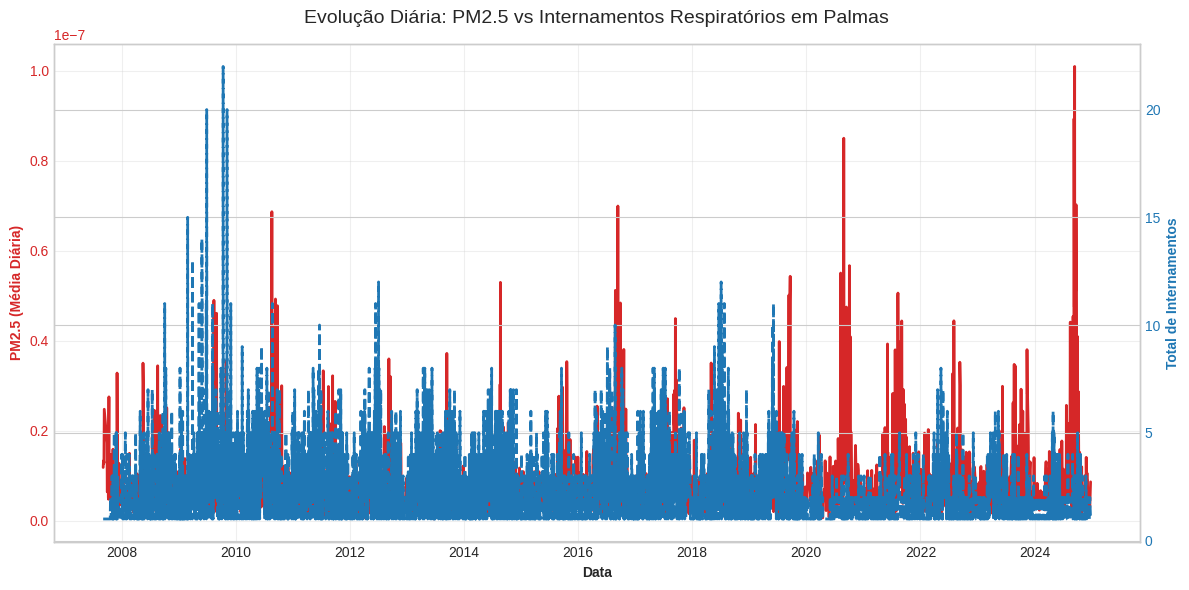

In [112]:
df_total_internamentos = df_final[['total_internamentos', 'DT_INTER']]

fig, ax1 = plt.subplots(figsize=(12, 6))

cor_pm = 'tab:red'
ax1.set_xlabel('Data', fontweight='bold')
ax1.set_ylabel('PM2.5 (Média Diária)', color=cor_pm, fontweight='bold')
ax1.plot(df_final['DT_INTER'], df_final['pm2p5'], color=cor_pm, linewidth=2, label='Poluição (PM2.5)')
ax1.tick_params(axis='y', labelcolor=cor_pm)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()

cor_int = 'tab:blue'
ax2.set_ylabel('Total de Internamentos', color=cor_int, fontweight='bold')
ax2.plot(df_final['DT_INTER'], df_final['total_internamentos'], color=cor_int, linewidth=2, linestyle='--', label='Internamentos')
ax2.tick_params(axis='y', labelcolor=cor_int)

plt.title('Evolução Diária: PM2.5 vs Internamentos Respiratórios em Palmas', fontsize=14, pad=15)
fig.tight_layout()

plt.show()